## Dataset Description: College Scorecard

The **College Scorecard** dataset from the U.S. Department of Education contains comprehensive data on U.S. colleges and universities, including admission rates, student demographics, costs, and outcomes.

### Task:
Predict whether an institution is **selective** (admission rate < 50%) based on institutional characteristics and student demographics.

### Key Columns:
- **SCHOOL_NAME**: Institution name
- **ADMISSION_RATE**: Overall admission rate (used to create target)
- **SAT_AVG**: Average SAT scores
- **STUDENT_SIZE**: Undergraduate enrollment
- **PREDOMINANT_DEGREE**: Predominant degree awarded
- **LOCALE**: Institution locale (city, suburb, town, rural)
- **PCT_WHITE/BLACK/HISPANIC/ASIAN**: Race/ethnicity demographic percentages
- **PCT_FEMALE**: Percentage of female students
- **PELL_RATE**: Percent receiving Pell Grants (socioeconomic proxy)
- **SELECTIVE**: Target variable (1: admission rate < 50%, 0: otherwise)

### Fairness Considerations:
Sensitive attributes include **race/ethnicity demographics**, **PCT_FEMALE** (gender), and **PELL_RATE** (socioeconomic status).

## 1. Data Downloading
Downloading College Scorecard data from the U.S. Department of Education API.

In [4]:
import os
import pandas as pd
import numpy as np
import requests
from sklearn.model_selection import train_test_split
import time

DATASET_NAME = "college-scorecard"
API_KEY = "b2uiD1hLpLFGxckoJZ1TdcOdsmf5c5GQSeExcRTe"
BASE_URL = "https://api.data.gov/ed/collegescorecard/v1/schools"

OUTPUT_DIR = f"../../resources/datasets/{DATASET_NAME}"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Define fields to fetch
fields = [
    "id",
    "school.name",
    "school.state",
    "school.city",
    "school.locale",
    "school.degrees_awarded.predominant",
    "latest.admissions.admission_rate.overall",
    "latest.admissions.sat_scores.average.overall",
    "latest.student.size",
    "latest.student.demographics.race_ethnicity.white",
    "latest.student.demographics.race_ethnicity.black",
    "latest.student.demographics.race_ethnicity.hispanic",
    "latest.student.demographics.race_ethnicity.asian",
    "latest.student.demographics.race_ethnicity.aian",
    "latest.student.demographics.race_ethnicity.nhpi",
    "latest.student.demographics.female_share",
    "latest.aid.pell_grant_rate",
    "latest.cost.tuition.in_state",
    "latest.completion.completion_rate_4yr_150nt",
]

fields_str = ",".join(fields)

print("Fetching College Scorecard data via API...")
print("This will take 1-2 minutes to fetch institutions with admission data...")

# Fetch data with pagination
all_data = []
page = 0
per_page = 100

while True:
    params = {
        "api_key": API_KEY,
        "fields": fields_str,
        "per_page": per_page,
        "page": page,
        "latest.admissions.admission_rate.overall__range": "0..1",  # Only schools with admission rate data
    }
    
    response = requests.get(BASE_URL, params=params)
    
    if response.status_code != 200:
        print(f"Error: {response.status_code}")
        print(response.text)
        break
    
    data = response.json()
    results = data.get("results", [])
    
    if not results:
        break
    
    all_data.extend(results)
    print(f"Fetched page {page}: {len(results)} schools (Total: {len(all_data)})")
    
    page += 1
    time.sleep(0.1)  # Rate limiting courtesy
    
    # Safety limit
    if page > 100:
        break

print(f"\nTotal schools fetched: {len(all_data)}")

# Convert to DataFrame
df = pd.DataFrame(all_data)
print(f"Initial shape: {df.shape}")
print(f"Columns: {df.columns.tolist()[:10]}...")  # Show first 10

# Flatten nested column names (API returns dotted names)
df.columns = [col.replace('latest.', '').replace('school.', '').replace('admissions.', '').replace('student.', '').replace('demographics.', '').replace('aid.', '').replace('cost.', '').replace('completion.', '') for col in df.columns]

print(f"\nFlattened columns: {df.columns.tolist()}")

# Data cleaning
print("\nCleaning data...")

# Convert numeric columns
numeric_cols = [
    'admission_rate.overall',
    'sat_scores.average.overall',
    'size',
    'race_ethnicity.white',
    'race_ethnicity.black',
    'race_ethnicity.hispanic',
    'race_ethnicity.asian',
    'race_ethnicity.aian',
    'race_ethnicity.nhpi',
    'female_share',
    'pell_grant_rate',
    'tuition.in_state',
    'completion_rate_4yr_150nt',
    'degrees_awarded.predominant',
    'locale',
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Rename for clarity
rename_map = {
    'admission_rate.overall': 'ADMISSION_RATE',
    'sat_scores.average.overall': 'SAT_AVG',
    'size': 'STUDENT_SIZE',
    'race_ethnicity.white': 'PCT_WHITE',
    'race_ethnicity.black': 'PCT_BLACK',
    'race_ethnicity.hispanic': 'PCT_HISPANIC',
    'race_ethnicity.asian': 'PCT_ASIAN',
    'race_ethnicity.aian': 'PCT_AIAN',
    'race_ethnicity.nhpi': 'PCT_NHPI',
    'female_share': 'PCT_FEMALE',
    'pell_grant_rate': 'PELL_RATE',
    'tuition.in_state': 'TUITION',
    'completion_rate_4yr_150nt': 'COMPLETION_RATE',
    'degrees_awarded.predominant': 'PREDOMINANT_DEGREE',
    'name': 'SCHOOL_NAME',
    'state': 'STATE',
    'city': 'CITY',
    'locale': 'LOCALE',
}

df = df.rename(columns=rename_map)

# Filter to schools with admission rate data
df = df[df['ADMISSION_RATE'].notna()].copy()
print(f"After filtering for admission rate: {df.shape}")

# Create binary target: Selective (admission rate < 0.5)
df['SELECTIVE'] = (df['ADMISSION_RATE'] < 0.5).astype(int)

print(f"\nTarget distribution:")
print(df['SELECTIVE'].value_counts())
print(f"Selective rate: {df['SELECTIVE'].mean():.2%}")

# Select final features
feature_cols = [
    'SAT_AVG',
    'STUDENT_SIZE',
    'PCT_WHITE',
    'PCT_BLACK',
    'PCT_HISPANIC',
    'PCT_ASIAN',
    'PCT_FEMALE',
    'PELL_RATE',
    'TUITION',
    'COMPLETION_RATE',
    'PREDOMINANT_DEGREE',
    'LOCALE',
    'SELECTIVE'
]

available_features = [col for col in feature_cols if col in df.columns]
df_final = df[available_features].copy()

# Drop rows with too many missing values
df_final = df_final.dropna(subset=['SAT_AVG', 'STUDENT_SIZE'], how='any')

# Fill remaining missing values with median
for col in df_final.columns:
    if col not in ['SELECTIVE', 'SCHOOL_NAME']:
        if df_final[col].dtype in ['float64', 'int64']:
            df_final[col] = df_final[col].fillna(df_final[col].median())

print(f"\nAfter cleaning: {df_final.shape}")
print(f"Final columns: {df_final.columns.tolist()}")

# Split into Train/Test
train_df, test_df = train_test_split(
    df_final,
    test_size=0.2,
    random_state=42,
    stratify=df_final['SELECTIVE']
)

# Save
train_path = os.path.join(OUTPUT_DIR, "train.csv")
test_path = os.path.join(OUTPUT_DIR, "test.csv")

train_df.to_csv(train_path, index=False)
test_df.to_csv(test_path, index=False)

print(f"\nSaved train.csv to {train_path}")
print(f"Saved test.csv to {test_path}")
print(f"Train shape: {train_df.shape}, Test shape: {test_df.shape}")
print(f"\nSensitive attributes for fairness analysis:")
print(f"  - PCT_WHITE/BLACK/HISPANIC/ASIAN: Race/ethnicity percentages")
print(f"  - PCT_FEMALE: Gender representation")
print(f"  - PELL_RATE: Socioeconomic status (% receiving Pell Grants)")

Fetching College Scorecard data via API...
This will take 1-2 minutes to fetch institutions with admission data...
Fetched page 0: 100 schools (Total: 100)
Fetched page 1: 100 schools (Total: 200)
Fetched page 2: 100 schools (Total: 300)
Fetched page 3: 100 schools (Total: 400)
Fetched page 4: 100 schools (Total: 500)
Fetched page 5: 100 schools (Total: 600)
Fetched page 6: 100 schools (Total: 700)
Fetched page 7: 100 schools (Total: 800)
Fetched page 8: 100 schools (Total: 900)
Fetched page 9: 100 schools (Total: 1000)
Fetched page 10: 100 schools (Total: 1100)
Fetched page 11: 100 schools (Total: 1200)
Fetched page 12: 100 schools (Total: 1300)
Fetched page 13: 100 schools (Total: 1400)
Fetched page 14: 100 schools (Total: 1500)
Fetched page 15: 100 schools (Total: 1600)
Fetched page 16: 100 schools (Total: 1700)
Fetched page 17: 100 schools (Total: 1800)
Fetched page 18: 100 schools (Total: 1900)
Fetched page 19: 46 schools (Total: 1946)

Total schools fetched: 1946
Initial shape: (

## 2. Baseline Model
Training a Random Forest classifier to predict college selectivity without any fairness considerations.

In [5]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Load data
DATASET_DIR = "../../resources/datasets/college-scorecard"
train = pd.read_csv(f"{DATASET_DIR}/train.csv")
test = pd.read_csv(f"{DATASET_DIR}/test.csv")

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")

# Features and target
X_train = train.drop(columns=["SELECTIVE"])
y_train = train["SELECTIVE"]
X_test = test.drop(columns=["SELECTIVE"])
y_test = test["SELECTIVE"]

# One-hot encode categorical variables
full = pd.concat([X_train, X_test], axis=0)
full_enc = pd.get_dummies(
    full, columns=["LOCALE", "PREDOMINANT_DEGREE"], drop_first=True
)

X_train_enc = full_enc.iloc[:len(X_train), :].reset_index(drop=True)
X_test_enc = full_enc.iloc[len(X_train):, :].reset_index(drop=True)

print(f"Encoded features: {X_train_enc.shape[1]} columns")

# Initialize model
rf_baseline = RandomForestClassifier(random_state=42, n_jobs=-1)

# 5-fold stratified CV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    rf_baseline, X_train_enc, y_train, cv=skf, scoring="accuracy", n_jobs=-1
)
print(f"\nMean CV Accuracy: {cv_scores.mean():.4f}")

# Retrain on full data and predict
rf_baseline.fit(X_train_enc, y_train)
y_pred = rf_baseline.predict(X_test_enc)
y_pred_proba = rf_baseline.predict_proba(X_test_enc)[:, 1]

# Save predictions
test_with_predictions = test.copy()
test_with_predictions['y_pred'] = y_pred
test_with_predictions['y_pred_proba'] = y_pred_proba
test_with_predictions.to_csv(f"{DATASET_DIR}/test_with_baseline_predictions.csv", index=False)

print(f"✓ Predictions saved to test_with_baseline_predictions.csv")

Train shape: (860, 13)
Test shape: (216, 13)
Encoded features: 23 columns

Mean CV Accuracy: 0.9163
✓ Predictions saved to test_with_baseline_predictions.csv


## 3. Fairness Analysis

We evaluate the baseline model using standard fairness metrics across demographic groups:

### Fairness Metrics:

1. **Demographic Parity Difference (DPD)**
   - Measures difference in positive prediction rates between groups
   - Formula: $P(\hat{Y}=1|A=a) - P(\hat{Y}=1|A=b)$
   - Ideal value: 0 (equal positive rates)
   - Acceptable range: [-0.1, 0.1]

2. **Equal Opportunity Difference (EOD)**
   - Measures difference in True Positive Rates between groups
   - Formula: $TPR_a - TPR_b$ where $TPR = P(\hat{Y}=1|Y=1, A=a)$
   - Ideal value: 0 (equal TPR)
   - Acceptable range: [-0.1, 0.1]

3. **Equalized Odds (EO)**
   - Both TPR and FPR should be equal across groups
   - Combines Equal Opportunity with False Positive Rate parity

### Sensitive Attributes:
- **PCT_BLACK**: Percentage of Black students (proxy for HBCUs and minority-serving institutions)
- **PCT_HISPANIC**: Percentage of Hispanic students (proxy for HSIs)
- **PELL_RATE**: Pell Grant recipients (socioeconomic status)
- **PCT_FEMALE**: Percentage of female students (gender representation)


FAIRNESS METRICS - BASELINE MODEL
            Attribute       DPD DPD_Pass       EOD EOD_Pass
       Black students -0.092593        ✓ -0.311111        ✗
    Hispanic students  0.111111        ✗  0.141762        ✗
       Asian students  0.240741        ✗  0.677419        ✗
      Female students -0.148148        ✗ -0.320513        ✗
Pell recipients (SES) -0.240741        ✗ -0.777778        ✗

Threshold: ±0.1 for both DPD and EOD


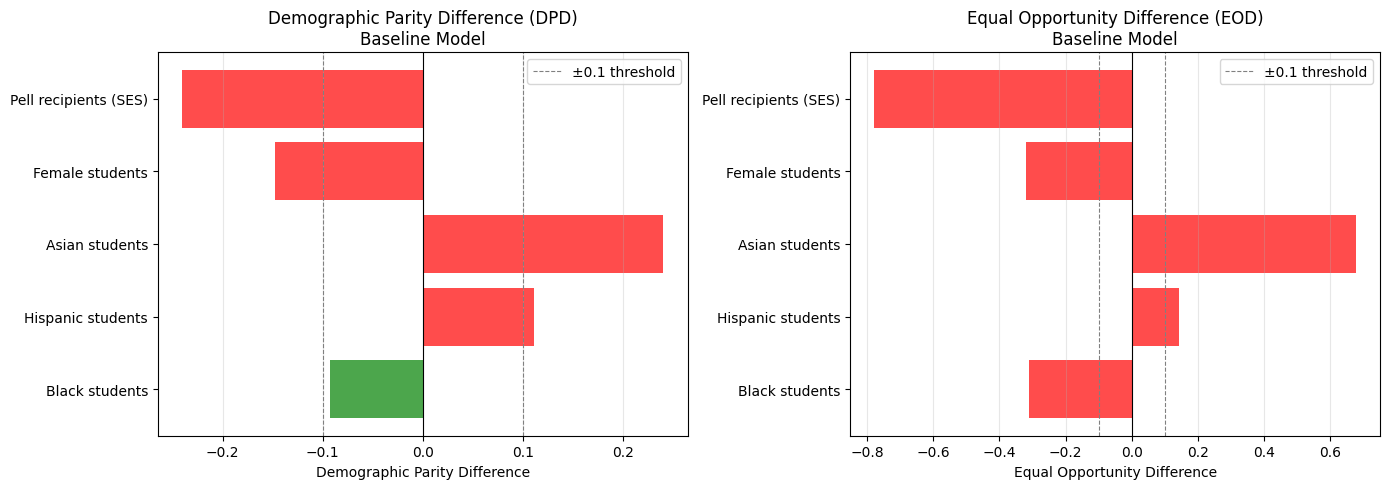


✓ Saved: baseline_fairness_metrics.png


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load predictions
DATASET_DIR = "../../resources/datasets/college-scorecard"
df = pd.read_csv(f"{DATASET_DIR}/test_with_baseline_predictions.csv")

# Define fairness metric functions
def demographic_parity_difference(y_true, y_pred, sensitive_attr):
    """Calculate DPD between two groups split by median"""
    median_val = sensitive_attr.median()
    group_a_mask = sensitive_attr >= median_val
    group_b_mask = sensitive_attr < median_val
    
    pr_a = y_pred[group_a_mask].mean()
    pr_b = y_pred[group_b_mask].mean()
    dpd = pr_a - pr_b
    
    return dpd, pr_a, pr_b

def equal_opportunity_difference(y_true, y_pred, sensitive_attr):
    """Calculate EOD (difference in TPR) between two groups"""
    median_val = sensitive_attr.median()
    group_a_mask = sensitive_attr >= median_val
    group_b_mask = sensitive_attr < median_val
    
    y_true_a = y_true[group_a_mask]
    y_pred_a = y_pred[group_a_mask]
    y_true_b = y_true[group_b_mask]
    y_pred_b = y_pred[group_b_mask]
    
    tpr_a = ((y_pred_a == 1) & (y_true_a == 1)).sum() / y_true_a.sum() if y_true_a.sum() > 0 else 0
    tpr_b = ((y_pred_b == 1) & (y_true_b == 1)).sum() / y_true_b.sum() if y_true_b.sum() > 0 else 0
    eod = tpr_a - tpr_b
    
    return eod, tpr_a, tpr_b

# Calculate fairness metrics
sensitive_attrs = {
    'PCT_BLACK': 'Black students',
    'PCT_HISPANIC': 'Hispanic students',
    'PCT_ASIAN': 'Asian students',
    'PCT_FEMALE': 'Female students',
    'PELL_RATE': 'Pell recipients (SES)'
}

results = []

for attr, label in sensitive_attrs.items():
    if attr not in df.columns:
        continue
    
    dpd, pr_high, pr_low = demographic_parity_difference(
        df['SELECTIVE'], df['y_pred'], df[attr]
    )
    eod, tpr_high, tpr_low = equal_opportunity_difference(
        df['SELECTIVE'], df['y_pred'], df[attr]
    )
    
    results.append({
        'Attribute': label,
        'DPD': dpd,
        'DPD_Pass': '✓' if abs(dpd) <= 0.1 else '✗',
        'EOD': eod,
        'EOD_Pass': '✓' if abs(eod) <= 0.1 else '✗'
    })

# Display results
results_df = pd.DataFrame(results)
print("\n" + "="*70)
print("FAIRNESS METRICS - BASELINE MODEL")
print("="*70)
print(results_df.to_string(index=False))
print("\nThreshold: ±0.1 for both DPD and EOD")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# DPD plot
ax1 = axes[0]
colors = ['green' if abs(x) <= 0.1 else 'red' for x in results_df['DPD']]
ax1.barh(results_df['Attribute'], results_df['DPD'], color=colors, alpha=0.7)
ax1.axvline(0, color='black', linestyle='-', linewidth=0.8)
ax1.axvline(0.1, color='gray', linestyle='--', linewidth=0.8, label='±0.1 threshold')
ax1.axvline(-0.1, color='gray', linestyle='--', linewidth=0.8)
ax1.set_xlabel('Demographic Parity Difference')
ax1.set_title('Demographic Parity Difference (DPD)\nBaseline Model')
ax1.legend()
ax1.grid(axis='x', alpha=0.3)

# EOD plot
ax2 = axes[1]
colors = ['green' if abs(x) <= 0.1 else 'red' for x in results_df['EOD']]
ax2.barh(results_df['Attribute'], results_df['EOD'], color=colors, alpha=0.7)
ax2.axvline(0, color='black', linestyle='-', linewidth=0.8)
ax2.axvline(0.1, color='gray', linestyle='--', linewidth=0.8, label='±0.1 threshold')
ax2.axvline(-0.1, color='gray', linestyle='--', linewidth=0.8)
ax2.set_xlabel('Equal Opportunity Difference')
ax2.set_title('Equal Opportunity Difference (EOD)\nBaseline Model')
ax2.legend()
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(f"{DATASET_DIR}/baseline_fairness_metrics.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved: baseline_fairness_metrics.png")